Fitted coefficients: [ 0.10747054 -2.63811704]
Mean Squared Error for fit between indices 4 and 38: 0.06692838510037091


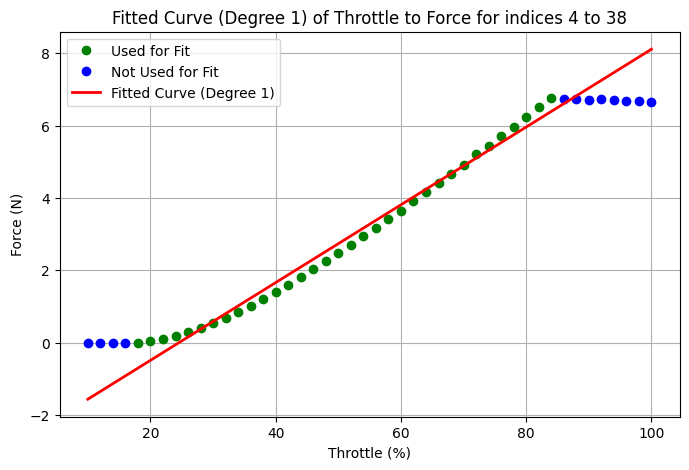

Fitted coefficients: [ 7.21407450e-04  3.38869761e-02 -1.03947813e+00]
Mean Squared Error for fit between indices 4 and 38: 0.005376240903068368


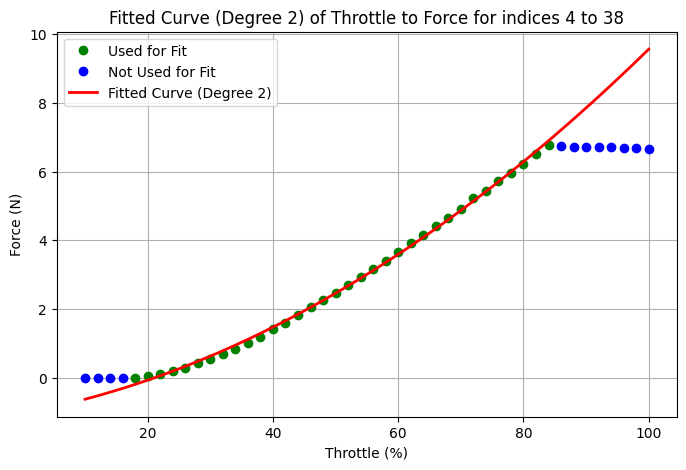

Mean Squared Error for fit between 0 and 84% throttles: 0.2888691898972493


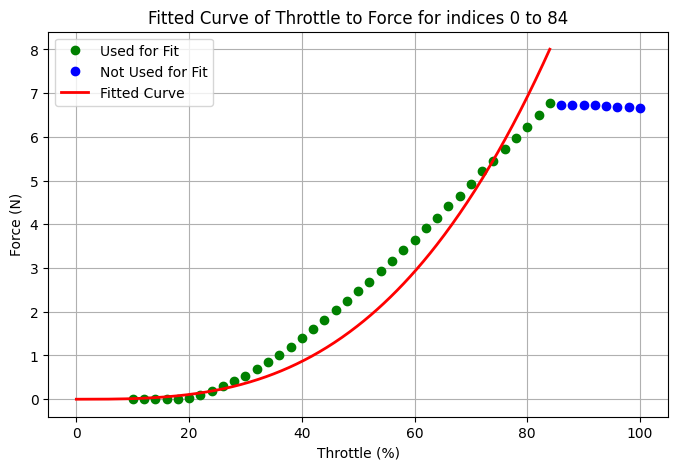

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Data
throttles = np.arange(10, 101, 2)
weights_thrust = np.array([
    0.00, 0.00, 0.00, 0.00, 0.00, 4.00, 11.00, 19.00, 30.00, 42.00,
    55.00, 70.30, 86.00, 102.70, 121.90, 142.90, 162.90, 184.60, 208.20,
    229.40, 252.70, 274.30, 300.10, 323.30, 347.50, 371.70, 398.60,
    423.20, 450.30, 474.20, 501.10, 531.80, 555.10, 582.40, 608.20,
    635.10, 663.10, 690.40, 686.80, 685.20, 684.90, 685.50, 683.20,
    680.50, 681.40, 679.20
])

FIT_SPACE_THRUST = [4, 38]  # indices for fitting range

# Convert weights to force (N)
throttles_to_force = 9.81 / 1000 * weights_thrust

def fit(x, y, degree, fit_space):
    # polynomial fit on selected range
    coefficients = np.polyfit(x[fit_space[0]:fit_space[1]], y[fit_space[0]:fit_space[1]], degree)

    print("Fitted coefficients:", coefficients)

    x_fit = np.linspace(x.min(), x.max(), 500)
    y_fit = np.polyval(coefficients, x_fit)

    mse = np.mean((y[fit_space[0]:fit_space[1]] - np.polyval(coefficients, x[fit_space[0]:fit_space[1]]))**2)
    print(f"Mean Squared Error for fit between indices {fit_space[0]} and {fit_space[1]}: {mse}")

    plt.figure(figsize=(8,5))
    plt.plot(x[fit_space[0]:fit_space[1]], y[fit_space[0]:fit_space[1]], 'go', label='Used for Fit')

    # Points not used for fitting
    mask = np.ones_like(x, dtype=bool)
    mask[fit_space[0]:fit_space[1]] = False
    plt.plot(x[mask], y[mask], 'bo', label='Not Used for Fit')

    # Plot the quadratic fit
    plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fitted Curve (Degree {degree})')

    plt.xlabel('Throttle (%)')
    plt.ylabel('Force (N)')
    plt.title(f'Fitted Curve (Degree {degree}) of Throttle to Force for indices {fit_space[0]} to {fit_space[1]}')
    plt.legend()
    plt.grid(True)
    plt.show()

    return coefficients

def fit_x_moved_parabel(x, y, fit_space, degree=2):
    mask = (x >= fit_space[0]) & (x <= fit_space[1])

    x_fit = x[mask]
    y_fit = y[mask]
    A = (x_fit - fit_space[0]) ** degree

    # convert to 2D array for lstsq
    A = A.reshape(-1, 1)

    coeffs, residuals, rank, s = np.linalg.lstsq(A, y_fit, rcond=None)
    y_fit_pred = coeffs[0] * (x_fit - fit_space[0]) ** degree

    mse = np.mean((y_fit - y_fit_pred)**2)
    print(f"Mean Squared Error for fit between {fit_space[0]} and {fit_space[1]}% throttles: {mse}")

    plt.figure(figsize=(8,5))
    plt.plot(x_fit, y_fit, 'go', label='Used for Fit')

    # Points not used for fitting
    plt.plot(x[~mask], y[~mask], 'bo', label='Not Used for Fit')

    # Plot the quadratic fit
    x_pred = np.linspace(fit_space[0], fit_space[1], 500)
    y_pred = coeffs[0] * (x_pred - fit_space[0]) ** degree

    plt.plot(x_pred, y_pred, 'r-', linewidth=2, label='Fitted Curve')

    plt.xlabel('Throttle (%)')
    plt.ylabel('Force (N)')
    plt.title(f'Fitted Curve of Throttle to Force for indices {fit_space[0]} to {fit_space[1]}')
    plt.legend()
    plt.grid(True)
    plt.show()



fit(throttles, throttles_to_force, degree=1, fit_space=FIT_SPACE_THRUST)
force_coeffs_2d = fit(throttles, throttles_to_force, degree=2, fit_space=FIT_SPACE_THRUST)
fit_x_moved_parabel(throttles, throttles_to_force, fit_space=[0, 84], degree=3)



Mean Squared Error for fit between 25 and 84% throttles: 9.738832088885739e-05


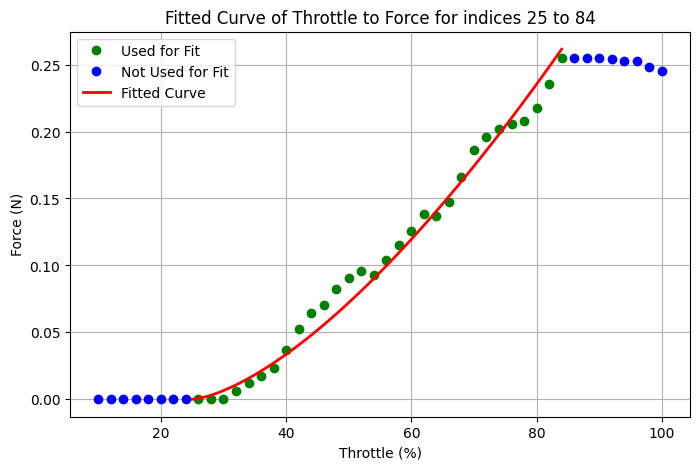

Fitted coefficients: [ 0.00460737 -0.1452505 ]
Mean Squared Error for fit between indices 10 and 38: 4.716340203483464e-05


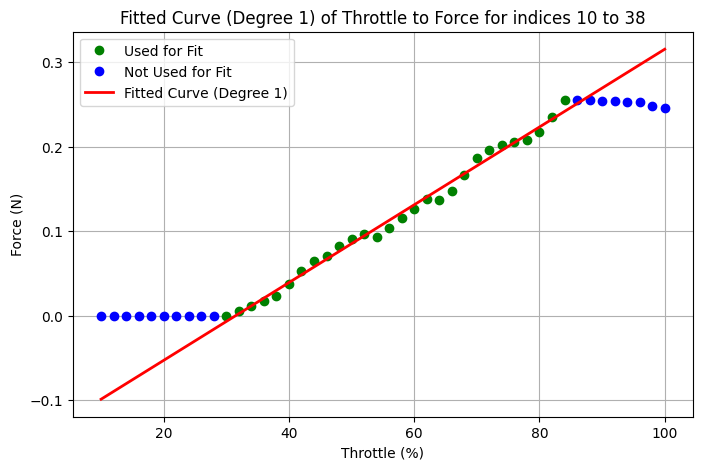

Fitted coefficients: [ 1.11602122e-05  3.33510674e-03 -1.11903786e-01]
Mean Squared Error for fit between indices 10 and 38: 4.0401813373190023e-05


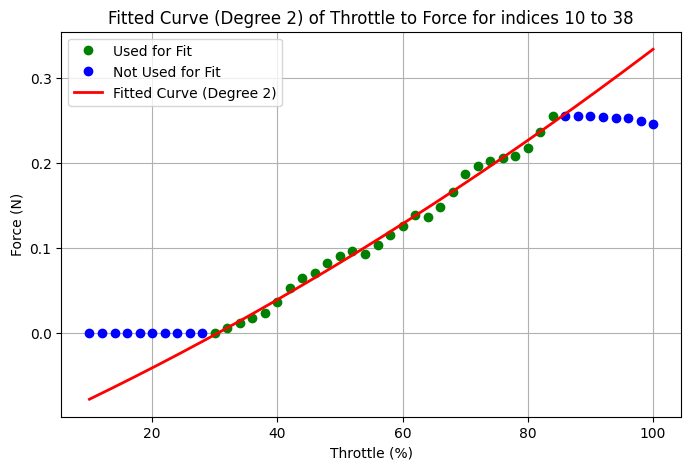

array([ 1.11602122e-05,  3.33510674e-03, -1.11903786e-01])

In [37]:
weights_torque = np.array([ 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 3.00, 6.00, 9.00, 12.00, 18.80, 26.80, 32.90, 36.00, 41.80, 46.10, 49.00, 47.50, 52.90, 58.60, 64.10, 70.60, 69.70, 75.30, 84.60, 95.10, 100.00, 103.10, 105.00, 106.00, 110.90, 120.10, 130.10, 130.00, 130.00, 
129.80, 129.50, 129.00, 128.90, 126.70, 125.10 ]) # in grams

FIT_SPACE_TORQUE = [10, 38]  # indices for fitting range
throttles_to_torque = 9.81 / 1000 * 0.2 * weights_torque

fit_x_moved_parabel(throttles, throttles_to_torque, fit_space=[25, 84], degree=1.5)

# Convert weights to torque (Nm)
DISTANCE = 0.2  # meters

FORCES = np.polyval(force_coeffs_2d, throttles)

fit(throttles, throttles_to_torque, degree=1, fit_space=FIT_SPACE_TORQUE)
fit(throttles, throttles_to_torque, degree=2, fit_space=FIT_SPACE_TORQUE)



